In [4]:
!pip install -q kaggle
!pip install -q split-folders

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
!kaggle datasets download -d atulyakumar98/gundetection
!unzip -q gundetection.zip -d /content/gundetection

Dataset URL: https://www.kaggle.com/datasets/atulyakumar98/gundetection
License(s): CC0-1.0
100% 250M/250M [00:13<00:00, 20.1MB/s]



In [6]:
import os
for root, dirs, files in os.walk('/content/gundetection'):
    level = root.replace('/content/gundetection', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"{indent}  {f}")

gundetection/
  2819.jpg
  1739.txt
  168.jpg


In [7]:
import os

DATASET_DIR = '/content/gundetection'

files = os.listdir(DATASET_DIR)
jpg_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
txt_files = [f for f in files if f.lower().endswith('.txt')]

print(f"Total files: {len(files)}")
print(f"Images: {len(jpg_files)}")
print(f"Labels: {len(txt_files)}")

# Peek at one label file
sample_txt = os.path.join(DATASET_DIR, txt_files[0])
print(f"\nSample label file: {txt_files[0]}")
with open(sample_txt) as f:
    print(f.read())

Total files: 6000
Images: 3000
Labels: 3000

Sample label file: 1739.txt
1 0.50625 0.49583333333333335 0.925 0.975



In [8]:
import os
from collections import Counter

DATASET_DIR = '/content/gundetection'

class_counts = Counter()
txt_files = [f for f in os.listdir(DATASET_DIR) if f.endswith('.txt')]

for tf_name in txt_files:
    with open(os.path.join(DATASET_DIR, tf_name)) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[parts[0]] += 1

print("Class ID distribution:", class_counts)

# Also check for subfolders (in case there's a separate no-gun folder)
print("Subfolders in dataset:", [d for d in os.listdir(DATASET_DIR)
                                 if os.path.isdir(os.path.join(DATASET_DIR, d))])

Class ID distribution: Counter({'1': 3464})
Subfolders in dataset: []


In [9]:
!kaggle datasets download -d prasunroy/natural-images
!unzip -q natural-images.zip -d /content/natural_images

Dataset URL: https://www.kaggle.com/datasets/prasunroy/natural-images
License(s): CC-BY-NC-SA-4.0
100% 342M/342M [00:18<00:00, 19.6MB/s]



In [10]:
import os
NOGUN_SRC = '/content/natural_images/natural_images'
for sub in os.listdir(NOGUN_SRC):
    p = os.path.join(NOGUN_SRC, sub)
    if os.path.isdir(p):
        print(f"{sub}: {len(os.listdir(p))} images")

airplane: 727 images
cat: 885 images
fruit: 1000 images
dog: 702 images
car: 968 images
motorbike: 788 images
person: 986 images
flower: 843 images


In [11]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

GUN_DIR      = '/content/gundetection'
NOGUN_SRC    = '/content/natural_images/natural_images'
BASE_DIR     = '/content/classification_data'

random.seed(42)

gun_images = []
for fname in sorted(os.listdir(GUN_DIR)):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    label_path = os.path.join(GUN_DIR, os.path.splitext(fname)[0] + '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            if any(ln.strip() for ln in f):
                gun_images.append(os.path.join(GUN_DIR, fname))


n_gun = len(gun_images)
all_nogun = []
for sub in os.listdir(NOGUN_SRC):
    sub_path = os.path.join(NOGUN_SRC, sub)
    if not os.path.isdir(sub_path):
        continue
    for fname in os.listdir(sub_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_nogun.append(os.path.join(sub_path, fname))

random.shuffle(all_nogun)

nogun_images = all_nogun[:n_gun]

print(f"Gun images:    {len(gun_images)}")
print(f"No Gun images: {len(nogun_images)}")

def split_3way(items, seed=42):
    train, temp = train_test_split(items, test_size=0.30, random_state=seed)
    val, test   = train_test_split(temp,  test_size=0.50, random_state=seed)
    return train, val, test

gun_train,   gun_val,   gun_test   = split_3way(gun_images)
nogun_train, nogun_val, nogun_test = split_3way(nogun_images)

print(f"\nTrain: {len(gun_train)} Gun / {len(nogun_train)} No Gun")
print(f"Val:   {len(gun_val)} Gun / {len(nogun_val)} No Gun")
print(f"Test:  {len(gun_test)} Gun / {len(nogun_test)} No Gun")


for split in ['train', 'val', 'test']:
    for cls in ['Gun', 'No Gun']:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)


def copy_files(paths, dst_dir, prefix=''):
    for i, src in enumerate(paths):
        ext  = os.path.splitext(src)[1]
        name = f"{prefix}{i:06d}{ext}"
        shutil.copy(src, os.path.join(dst_dir, name))

copy_files(gun_train,   f'{BASE_DIR}/train/Gun',    'gun_')
copy_files(gun_val,     f'{BASE_DIR}/val/Gun',      'gun_')
copy_files(gun_test,    f'{BASE_DIR}/test/Gun',     'gun_')
copy_files(nogun_train, f'{BASE_DIR}/train/No Gun', 'nogun_')
copy_files(nogun_val,   f'{BASE_DIR}/val/No Gun',   'nogun_')
copy_files(nogun_test,  f'{BASE_DIR}/test/No Gun',  'nogun_')

print("\n✅ Final dataset structure:")
for split in ['train', 'val', 'test']:
    for cls in ['Gun', 'No Gun']:
        n = len(os.listdir(os.path.join(BASE_DIR, split, cls)))
        print(f"  {split}/{cls}: {n}")

Gun images:    3000
No Gun images: 3000

Train: 2100 Gun / 2100 No Gun
Val:   450 Gun / 450 No Gun
Test:  450 Gun / 450 No Gun

✅ Final dataset structure:
  train/Gun: 2100
  train/No Gun: 2100
  val/Gun: 450
  val/No Gun: 450
  test/Gun: 450
  test/No Gun: 450


In [12]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{BASE_DIR}/train', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    f'{BASE_DIR}/val', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary'
)
test_gen = val_test_datagen.flow_from_directory(
    f'{BASE_DIR}/test', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print("Class indices:", train_gen.class_indices)
# {'Gun': 0, 'No Gun': 1}

Found 4200 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'Gun': 0, 'No Gun': 1}


In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,679,041 (36.92 MB)

 Trainable params: 9,679,041 (36.92 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('/content/best_gun_model.keras',
                    save_best_only=True, monitor='val_loss')
]

history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 83s 562ms/step - accuracy: 0.6376 - loss: 0.6545 - val_accuracy: 0.7689 - val_loss: 0.4555
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 69s 524ms/step - accuracy: 0.7974 - loss: 0.4414 - val_accuracy: 0.9033 - val_loss: 0.2775
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 502ms/step - accuracy: 0.8514 - loss: 0.3475 - val_accuracy: 0.8789 - val_loss: 0.2893
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 63s 480ms/step - accuracy: 0.8771 - loss: 0.3034 - val_accuracy: 0.8711 - val_loss: 0.3365
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 70s 531ms/step - accuracy: 0.8860 - loss: 0.2814 - val_accuracy: 0.8633 - val_loss: 0.3970
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 64s 480ms/step - accuracy: 0.8917 - loss: 0.2634 - val_accuracy: 0.9344 - val_loss: 0.1741
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 63s 475ms/step - accuracy: 0.9031 - loss: 0.2560 - val_accuracy: 0.9033 - val_loss: 0.2355
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 62s 473ms/step - accuracy: 0.9038 - loss: 0

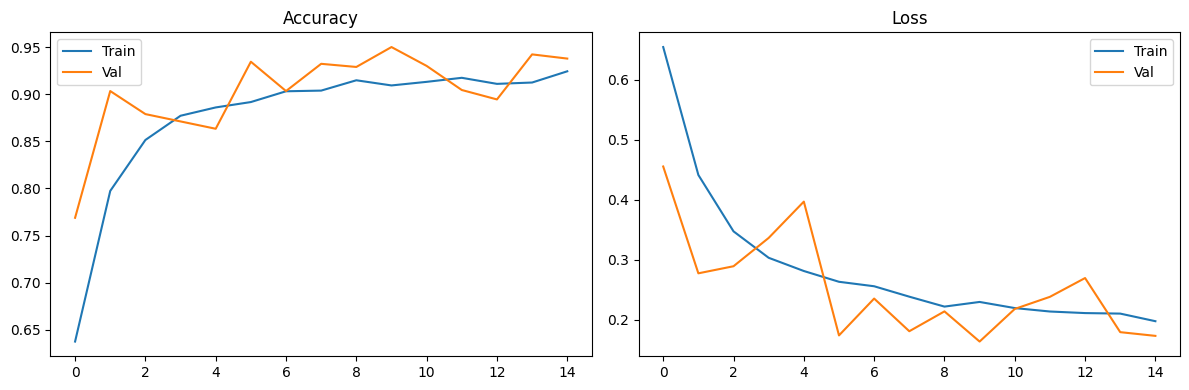

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'],     label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Accuracy'); ax[0].legend()

ax[1].plot(history.history['loss'],     label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title('Loss'); ax[1].legend()

plt.tight_layout(); plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model
model = tf.keras.models.load_model('/content/best_gun_model.keras')

test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

preds = (model.predict(test_gen) > 0.5).astype(int).flatten()
true  = test_gen.classes

print("\nClassification Report:")
print(classification_report(true, preds, target_names=['Gun', 'No Gun']))
print("Confusion Matrix:")
print(confusion_matrix(true, preds))

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.9333 - loss: 0.1846
Test Accuracy: 0.9333
Test Loss:     0.1846
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step

Classification Report:
              precision    recall  f1-score   support

         Gun       0.90      0.97      0.94       450
      No Gun       0.97      0.90      0.93       450

    accuracy                           0.93       900
   macro avg       0.94      0.93      0.93       900
weighted avg       0.94      0.93      0.93       900

Confusion Matrix:
[[437  13]
 [ 47 403]]


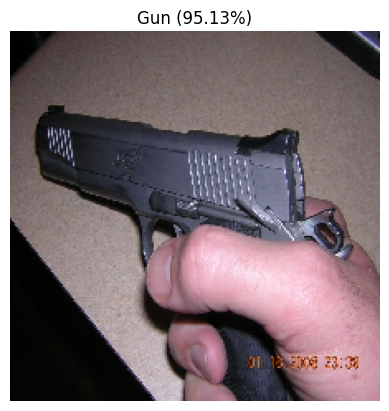

In [18]:
from tensorflow.keras.preprocessing import image as kimg

def predict(img_path):
    img = kimg.load_img(img_path, target_size=IMG_SIZE)
    arr = kimg.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, 0)
    p = model.predict(arr, verbose=0)[0][0]
    label = 'Gun' if p < 0.5 else 'No Gun'
    conf  = 1 - p if p < 0.5 else p

    plt.imshow(img); plt.axis('off')
    plt.title(f"{label} ({conf:.2%})"); plt.show()

predict(f'{BASE_DIR}/test/Gun/gun_000000.jpg')

Saving images.jpg to images.jpg


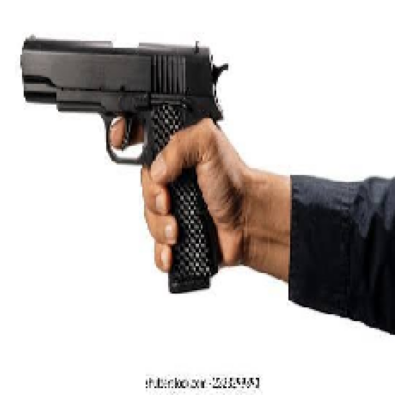

Prediction : Gun
Confidence : 99.39%


In [29]:
from google.colab import files
from tensorflow.keras.preprocessing import image as kimg
import matplotlib.pyplot as plt
import numpy as np

def predict_uploaded():
    uploaded = files.upload()

    for fname in uploaded.keys():
        img = kimg.load_img(fname, target_size=IMG_SIZE)
        arr = kimg.img_to_array(img) / 255.0
        arr = np.expand_dims(arr, 0)

        prob = model.predict(arr, verbose=0)[0][0]
        label = 'Gun' if prob < 0.5 else 'No Gun'
        conf  = 1 - prob if prob < 0.5 else prob

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.show()


        color = 'red' if label == 'Gun' else 'green'
        print(f"Prediction : {label}")
        print(f"Confidence : {conf:.2%}")

predict_uploaded()

Saving images.jpg to images (2).jpg


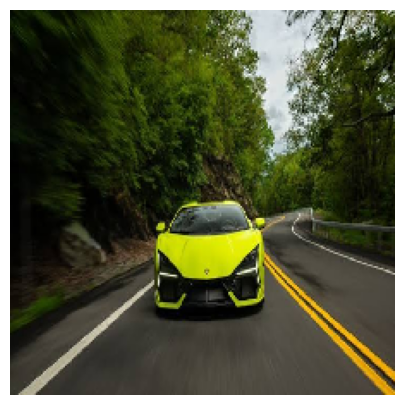

Prediction : No Gun
Confidence : 84.32%


In [31]:

def predict_uploaded():
    uploaded = files.upload()

    for fname in uploaded.keys():
        img = kimg.load_img(fname, target_size=IMG_SIZE)
        arr = kimg.img_to_array(img) / 255.0
        arr = np.expand_dims(arr, 0)

        prob = model.predict(arr, verbose=0)[0][0]
        label = 'Gun' if prob < 0.5 else 'No Gun'
        conf  = 1 - prob if prob < 0.5 else prob

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.show()


        color = 'red' if label == 'Gun' else 'green'
        print(f"Prediction : {label}")
        print(f"Confidence : {conf:.2%}")

predict_uploaded()